In [15]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub

In [16]:
"""PART 1: Data Collection"""
import requests #sends HTTP requests to APIs.
import pandas as pd

# Step 1: Call NASA POWER API for Cairo, 2 years daily data 
url = "https://power.larc.nasa.gov/api/temporal/daily/point" #Nasa API Endpoint

"""Parameters:
T2M_MAX: Maximum temperature at 2 meters (°C)
T2M_MIN: Minimum temperature at 2 meters (°C)
T2M: Mean daily temperature at 2 meters (°C)
PRECTOTCORR: Corrected precipitation (mm/day)
RH2M: Relative humidity at 2 meters (%)
"""

params = {
    "parameters": "T2M_MAX,T2M_MIN,T2M,PRECTOTCORR,RH2M",
    "community": "AG",
    "longitude": 31.2357,#Cairo Bounds
    "latitude": 30.0444,
    "start": "20230101",
    "end": "20241231",
    "format": "JSON"
}

response = requests.get(url, params=params)
data = response.json()

# Step 2: Extract the nested parameter dictionaries
params_data = data["properties"]["parameter"]

# Each parameter is a dict {date: value}, so we build a DataFrame from them
df = pd.DataFrame(params_data)

# Step 3: Turn the date string index into a real datetime index 
df.index = pd.to_datetime(df.index, format="%Y%m%d")
df.index.name = "date"

# Step 4: Rename columns to friendly names
df = df.rename(columns={
    "T2M": "temp_mean",
    "T2M_MAX": "temp_max",
    "T2M_MIN": "temp_min",
    "PRECTOTCORR": "precipitation",
    "RH2M": "humidity"
})

# Step 5: Replace NASA's missing-value code (-999) with NaN 
df = df.replace(-999, pd.NA)

# Step 6: Save raw JSON and cleaned CSV
import json
with open("cairo_weather_raw.json", "w") as f:
    json.dump(data, f)

df.to_csv("cairo_weather_clean.csv")

df.head()

,temp_max,temp_min,temp_mean,precipitation,humidity
date,,,,,
2023-01-01,21.20,10.54,14.71,0.06,76.77
2023-01-02,22.84,9.76,14.61,0.18,77.20
2023-01-03,20.40,8.92,13.95,0.38,79.83
2023-01-04,19.92,9.61,14.35,0.39,78.11
2023-01-05,19.47,7.82,13.09,0.05,74.68


In [17]:
"""PART 2: Data Preparation"""

# Step 1: Check for gaps in the daily date sequence 
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq="D")
missing_dates = full_range.difference(df.index)
print("Missing dates count:", len(missing_dates))

# Step 2: Check for duplicate timestamps 
print("Duplicate dates count:", df.index.duplicated().sum())

# Step 3: Count missing values (NaN) per column 
print(df.isna().sum())

# No missing values found, so no fill strategy needed

# Step 4: Confirm units are consistent
print(data["parameters"])

Missing dates count: 0
Duplicate dates count: 0
temp_max         0
temp_min         0
temp_mean        0
precipitation    0
humidity         0
dtype: int64
{'T2M_MAX': {'units': 'C', 'longname': 'Temperature at 2 Meters Maximum'}, 'T2M_MIN': {'units': 'C', 'longname': 'Temperature at 2 Meters Minimum'}, 'T2M': {'units': 'C', 'longname': 'Temperature at 2 Meters'}, 'PRECTOTCORR': {'units': 'mm/day', 'longname': 'Precipitation Corrected'}, 'RH2M': {'units': '%', 'longname': 'Relative Humidity at 2 Meters'}}


### API Documentation

**API:** NASA POWER Daily API

**Endpoint:** 
 https://power.larc.nasa.gov/api/temporal/daily/point

**Region:** 
Cairo, Egypt
Latitude: 30.0444
Longitude: 31.2357

**Time Range:** 
2023-01-01 to 2024-12-31 (2 years)

**Parameters:** 
- T2M_MAX : Maximum daily temperature (°C)
- T2M_MIN : Minimum daily temperature (°C)
- T2M : Mean daily temperature (°C)
- PRECTOTCORR : Daily precipitation (mm/day)
- RH2M : Relative humidity (%)

**Format:** 
JSON

**Rate Limits:** 
No rate limits were encountered during data collection.

In [18]:
"""PART 3: EDA"""

"""3.1 Descriptive overview """

import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Summary statistics for numeric columns 
df.describe()

,temp_max,temp_min,temp_mean,precipitation,humidity
count,731.000000,731.000000,731.000000,731.000000,731.000000
mean,30.474309,15.869754,22.632558,0.385677,53.115527
std,7.847167,6.079378,7.088304,2.750531,13.946815
min,13.750000,3.320000,8.320000,0.000000,18.260000
25%,22.990000,10.285000,15.825000,0.000000,42.740000
50%,31.200000,15.950000,22.920000,0.000000,51.680000
75%,38.175000,21.620000,29.730000,0.010000,64.245000
max,45.490000,27.510000,35.050000,42.540000,84.600000


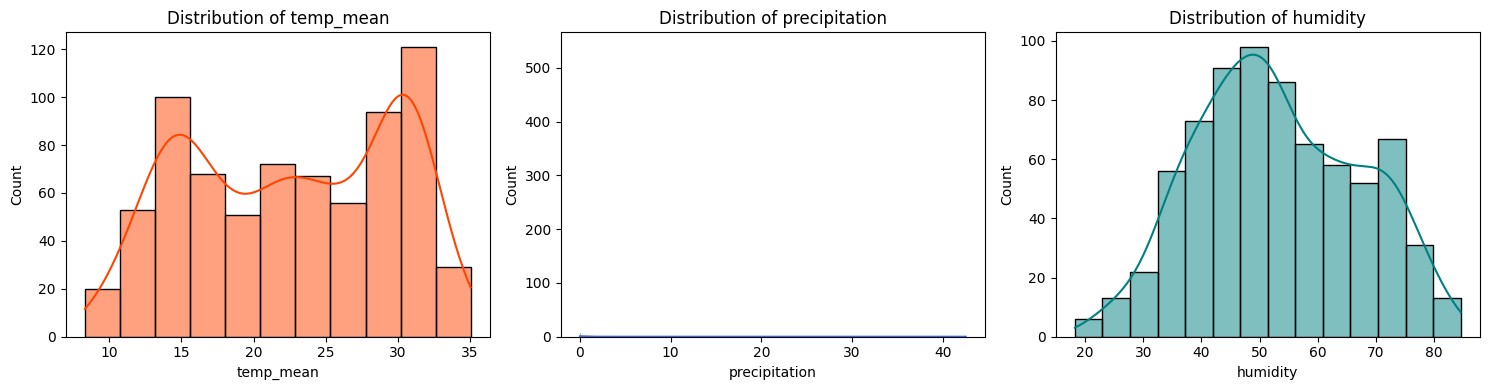

In [19]:
# Distribution plots (histogram + KDE)
columns = ["temp_mean", "precipitation", "humidity"]
colors = ["orangered", "royalblue", "teal"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes, columns, colors):
    sns.histplot(df[col], kde=True, color=color, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

### Temperature Distribution
The temperature distribution shows two main peaks around **15°C** and **30°C**, representing Cairo's two dominant seasons: **mild winters** and **hot summers**. This indicates that temperatures are concentrated around these typical seasonal values rather than being evenly distributed throughout the year.

### Precipitation Distribution
Precipitation values are concentrated near **0 mm**, showing that most days receive little or no rainfall. A small number of higher values represent occasional rain events, which is consistent with Cairo's dry desert climate.

### Humidity Distribution
Humidity follows an approximately **normal (bell-shaped) distribution** centered around **50%**. Most days have moderate humidity levels, with fewer days at very low or very high humidity. The distribution appears balanced, with no strong skewness or unusual patterns, suggesting consistent and reliable data.

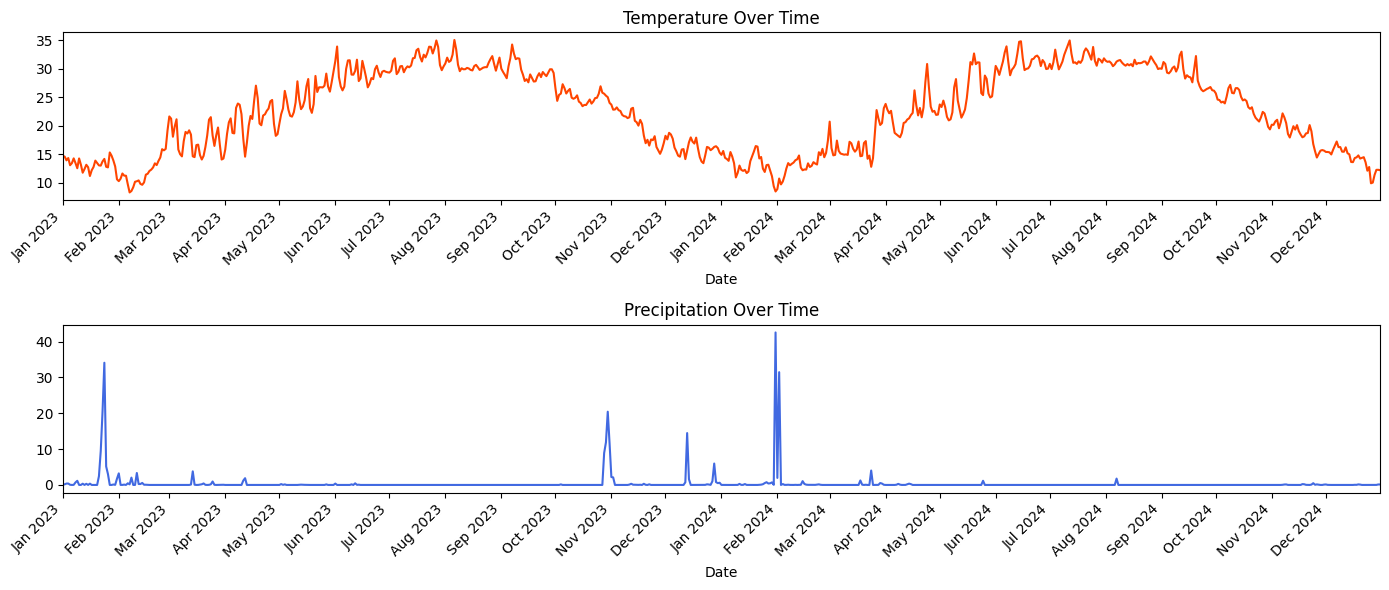

In [20]:
"""3.2 Temporal patterns"""

# Step 1: Line plot of temperature and precipitation over time 

import matplotlib.dates as mdates
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Temperature plot
df["temp_mean"].plot(ax=axes[0], color="orangered")
axes[0].set_title("Temperature Over Time")
axes[0].set_xlabel("Date")

# Precipitation plot
df["precipitation"].plot(ax=axes[1], color="royalblue")
axes[1].set_title("Precipitation Over Time")
axes[1].set_xlabel("Date")

# Show every month on both graphs
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

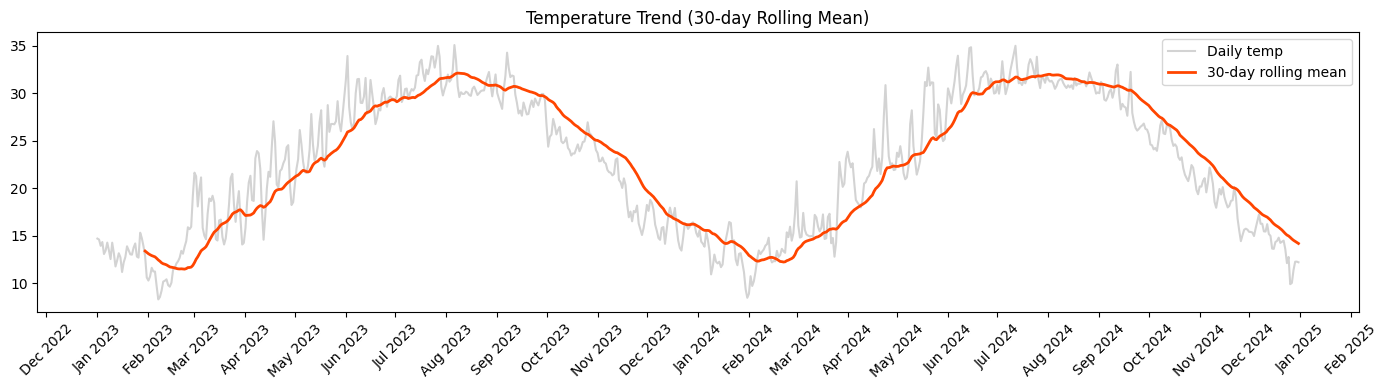

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
df["temp_roll_mean_30"] = df["temp_mean"].rolling(window=30).mean()
plt.figure(figsize=(14, 4))

plt.plot(df.index, df["temp_mean"], color="lightgray", label="Daily temp")
plt.plot(df.index, df["temp_roll_mean_30"], color="orangered", linewidth=2,
         label="30-day rolling mean")

# Show every month
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())          
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y")) 

plt.xticks(rotation=45)
plt.title("Temperature Trend (30-day Rolling Mean)")
plt.legend()
plt.tight_layout()
plt.show()

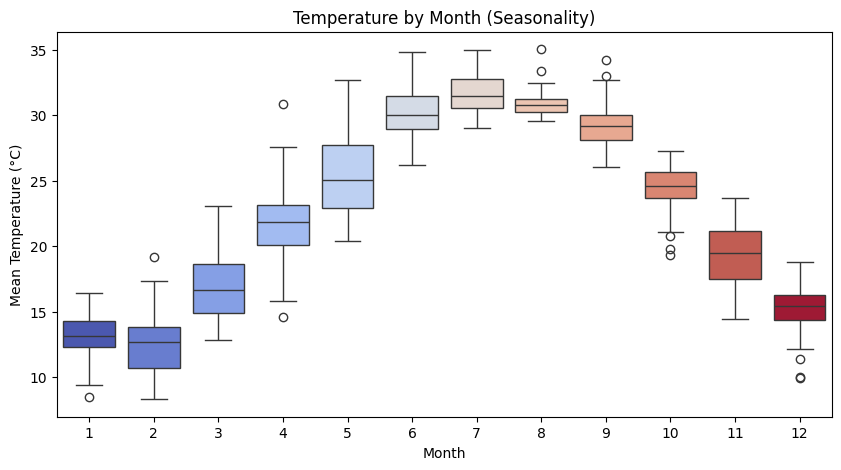

In [22]:
# Step 3: Seasonality - boxplot of temperature by month

df["month"] = df.index.month

plt.figure(figsize=(10, 5))

sns.boxplot(
    x="month",
    y="temp_mean",
    data=df,
    hue="month",
    palette="coolwarm",
    legend=False
)

plt.title("Temperature by Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Mean Temperature (°C)")
plt.show()

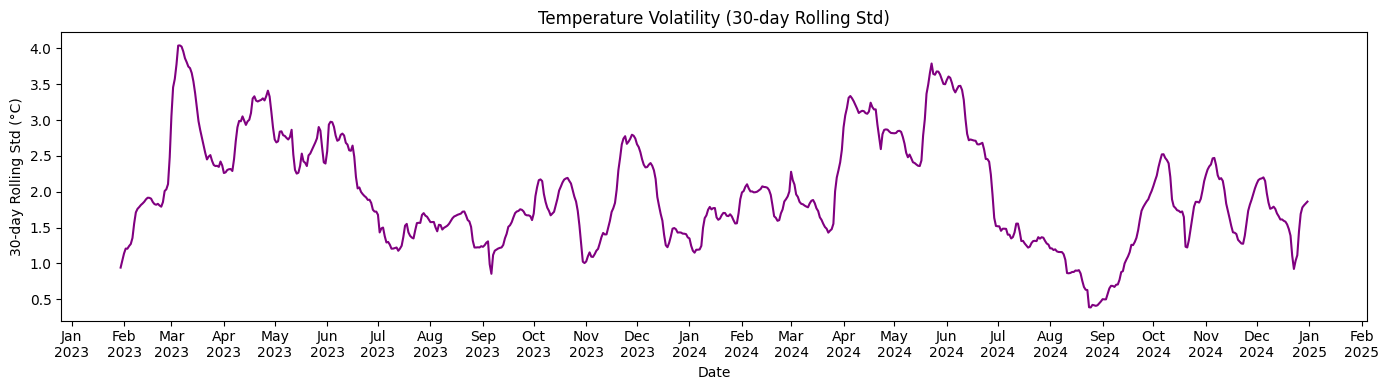

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Step 4: Rolling std to see local volatility
df["temp_roll_std_30"] = df["temp_mean"].rolling(window=30).std()

plt.figure(figsize=(14, 4))
plt.plot(df.index, df["temp_roll_std_30"], color="purple")

plt.title("Temperature Volatility (30-day Rolling Std)")
plt.xlabel("Date")
plt.ylabel("30-day Rolling Std (°C)")

# Show every month
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))  # Jan\n2023

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Temperature Over Time
Daily mean temperature in Cairo follows a clear seasonal cycle, peaking around **33–35°C in Jul–Aug** and dropping to **10–12°C in Feb** each year. The two years show a very similar pattern, indicating consistent seasonal temperature changes.

### Precipitation Over Time
Daily precipitation remains close to **0 mm** for most of the year, with rainfall occurring as short spikes mainly during winter. The largest rainfall events are approximately **40 mm in Feb 2024** and **34 mm in Feb 2023**, while **Jun–Sep** is almost completely dry.

### Temperature Trend (30-day Rolling Mean)
The **30-day rolling mean** smooths out daily fluctuations to highlight the long-term trend. It rises to about **32°C in Aug** and falls to around **12°C in Feb** during both years, confirming a stable seasonal cycle with no noticeable long-term warming over the study period.

### Temperature by Month (Seasonality)
Monthly temperatures show that **Jan, Feb, and Dec** are the coldest months (median temperatures around **13–15°C**), while **Jun, Jul, and Aug** are the hottest (around **30–32°C**). Summer temperatures are relatively consistent, whereas spring and autumn months (**Apr, May, Oct, and Nov**) exhibit greater variability.

### Temperature Volatility (30-day Rolling Standard Deviation)
The **30-day rolling standard deviation** measures how much daily temperatures vary over the previous 30 days. Higher values indicate greater day-to-day fluctuations, while lower values indicate more stable temperatures. Volatility reaches its highest levels (**~3.5–4°C**) during **Mar–Apr** and again around **Jun** (spring into early summer), as the transition into summer heat brings the most unstable temperatures. It also rises more mildly during **autumn (Oct–Dec), reaching around ~2.5–2.8°C**. The clearest low point occurs during **Aug–Sep 2024**, dropping to **~0.4–0.5°C**, when deep summer conditions keep temperatures steady from day to day. Overall, volatility spends most of the two-year period between **1°C and 3°C**, with spring and early-summer transitions being the most unstable periods each year.

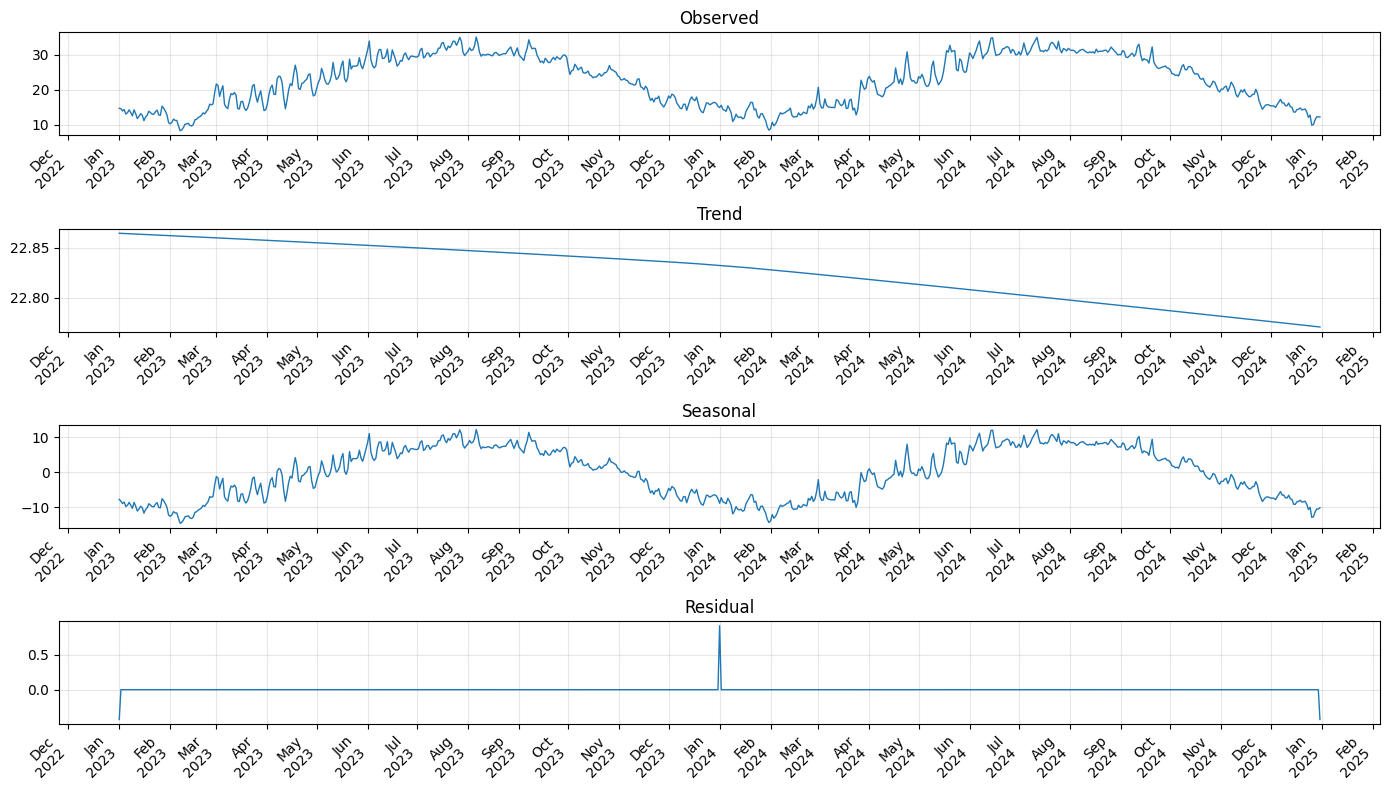

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import STL

# STL decomposition
stl = STL(df["temp_mean"], period=365)
result = stl.fit()

# Create separate subplots 
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=False)

components = [
    (df["temp_mean"], "Observed"),
    (result.trend, "Trend"),
    (result.seasonal, "Seasonal"),
    (result.resid, "Residual")
]

for ax, (series, title) in zip(axes, components):
    ax.plot(series.index, series, linewidth=1)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    # Show every month
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

    # Ensure labels appear on every subplot
    ax.tick_params(axis="x", labelbottom=True)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

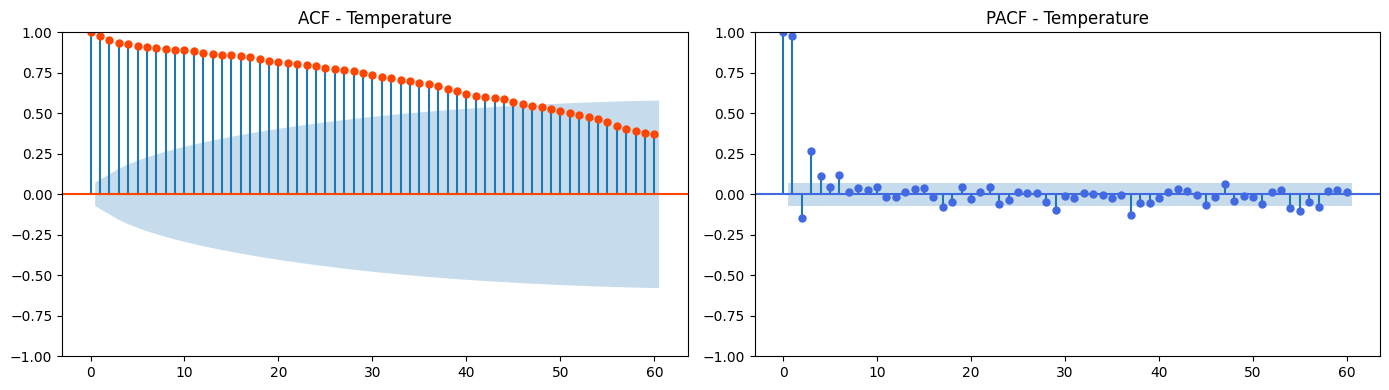

In [25]:
# Step 2: ACF and PACF plots to check periodicity/lag dependence
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df["temp_mean"], lags=60, ax=axes[0], color="orangered")
plot_pacf(df["temp_mean"], lags=60, ax=axes[1], color="royalblue")
axes[0].set_title("ACF - Temperature")
axes[1].set_title("PACF - Temperature")
plt.tight_layout()
plt.show()

In [26]:
# Step 3: Augmented Dickey-Fuller test for stationarity
adf_result = adfuller(df["temp_mean"])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Series is stationary (reject null hypothesis)")
else:
    print("Series is NOT stationary (fail to reject null hypothesis)")

ADF Statistic: -1.3204225648432852
p-value: 0.6197779492887928
Series is NOT stationary (fail to reject null hypothesis)


### Decomposition, ACF/PACF, and Stationarity

The STL decomposition shows the seasonal component dominates the series, while the trend is essentially flat (no meaningful long-term warming/cooling over the 2 years). One residual spike (~Jan 2024) suggests a short unusual weather event rather than a data error.

The ACF decays very slowly, staying correlated even at 60-day lags — a sign of strong seasonality rather than short-term memory. The PACF drops sharply after lag 1, meaning most of the dependency is seasonal, not autoregressive.

The Augmented Dickey-Fuller test confirms this: p-value = 0.62, meaning the series is **not stationary**. This is expected given the clear seasonal cycle — the mean temperature shifts predictably by month. For modeling, this implies the series would need seasonal differencing or a model that explicitly handles seasonality (e.g. SARIMA) rather than a plain ARIMA.

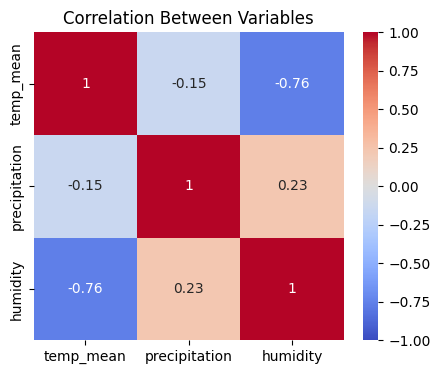

In [27]:
"""3.4 Relationships and anomalies"""

# Step 1: Correlation between temperature, precipitation, humidity
corr = df[["temp_mean", "precipitation", "humidity"]].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Variables")
plt.show()

In [28]:
# Step 2: Outlier detection using rolling z-score
# Rolling window is better than a fixed global threshold, since it adapts to seasonal norms
roll_mean = df["temp_mean"].rolling(window=30).mean()
roll_std = df["temp_mean"].rolling(window=30).std()
df["temp_zscore"] = (df["temp_mean"] - roll_mean) / roll_std

outliers = df[df["temp_zscore"].abs() > 3]
print("Number of temperature outliers:", len(outliers))
outliers[["temp_mean", "temp_zscore"]]

Number of temperature outliers: 6


,temp_mean,temp_zscore
date,,
2023-03-01,21.64,3.098744
2023-09-07,34.25,3.423263
2024-03-01,20.73,3.206330
2024-03-27,22.76,3.347397
2024-04-24,30.84,3.200705
2024-12-26,9.92,-3.398683


In [30]:
# Step 3: Flag suspicious/impossible values
# Negative rainfall or extreme temp spikes usually mean sensor/API errors, not real weather
suspicious = df[(df["precipitation"] < 0) | (df["temp_mean"] > 50) | (df["temp_mean"] < -20)]
print("Suspicious rows found:", len(suspicious))


Suspicious rows found: 0


### Correlation and Anomalies

Temperature and humidity show a strong negative correlation (-0.76) — hotter days are drier, consistent with Cairo's desert climate. Temperature and precipitation are weakly negatively correlated (-0.15), and precipitation and humidity show a weak positive correlation (0.23).

Rolling z-score outlier detection flagged 6 temperature outliers, all occurring during seasonal transition periods (early spring, late autumn) — matching the high-volatility windows identified earlier. These reflect real sudden temperature swings, not errors.

No suspicious values (negative rainfall or physically impossible temperatures) were found, indicating good overall data quality.

## Summary

This project analyzed daily weather data for **Cairo, Egypt** from **January 2023 to December 2024** (2 full years). The **NASA POWER API** was used because it requires no registration or API key, provides reliable long-term historical daily data by coordinates, and made it easy to pull two years of temperature, precipitation, and humidity data in a single request.

Temperature showed a **clear yearly seasonal cycle**, peaking around 33–35°C in summer (Jun–Aug) and dropping to around 10–13°C in winter (Dec–Feb), with both years following almost the same pattern — no long-term warming or cooling trend was found. Precipitation stayed close to 0 mm almost all year, consistent with Cairo's desert climate, with a few rain spikes concentrated mainly in winter. Volatility (day-to-day temperature swings) was highest during the spring transition (Mar–Jun) and lowest during peak summer, when weather is most stable.

The series was confirmed **not stationary** (ADF p-value = 0.62), which is expected given the strong seasonal pattern — the average temperature shifts predictably with the season rather than staying constant. This means any future forecasting model would need to account for seasonality (e.g. seasonal differencing or a model like SARIMA) rather than assuming a constant mean.

For data quality: the dataset had **no missing values, no date gaps, and no duplicate timestamps**, so no cleaning or interpolation was needed. Units were confirmed consistent directly from the API's metadata (°C, mm/day, %). A rolling z-score check flagged 6 temperature outliers, all occurring during seasonal transition periods — these reflect real sudden weather swings rather than sensor errors. No impossible values (like negative rainfall) were found, confirming the data was clean and reliable for analysis.